In [3]:
#import the needed libraries
import pandas as pd
import numpy as np

In [4]:
#Loading the CSV file and printing first 5 rows
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
#Data Inspection and Exploration
print(df.shape)
df.info()

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
#Dealing with duplicates

In [7]:
print(df.duplicated())
print(df.duplicated().sum())

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool
0


In [8]:
#Checking the categorical and numerical column
cat_col= [col for col in df.columns if df[col].dtype == 'object']
print('Categorical column:',cat_col)

num_col = [col for col in df.columns if df[col].dtype != 'object']
print('Numerical column',num_col)

Categorical column: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical column ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [9]:
#Uniqueness

In [10]:
df[cat_col].nunique()

Name        891
Sex           2
Ticket      681
Cabin       147
Embarked      3
dtype: int64

In [ ]:
#unwanted Coulmn

In [11]:
df1 = df.drop(columns=['Name','Ticket'])
print(df1)
print(df1.shape)

     PassengerId  Survived  Pclass     Sex   Age  SibSp  Parch     Fare Cabin  \
0              1         0       3    male  22.0      1      0   7.2500   NaN   
1              2         1       1  female  38.0      1      0  71.2833   C85   
2              3         1       3  female  26.0      0      0   7.9250   NaN   
3              4         1       1  female  35.0      1      0  53.1000  C123   
4              5         0       3    male  35.0      0      0   8.0500   NaN   
..           ...       ...     ...     ...   ...    ...    ...      ...   ...   
886          887         0       2    male  27.0      0      0  13.0000   NaN   
887          888         1       1  female  19.0      0      0  30.0000   B42   
888          889         0       3  female   NaN      1      2  23.4500   NaN   
889          890         1       1    male  26.0      0      0  30.0000  C148   
890          891         0       3    male  32.0      0      0   7.7500   NaN   

    Embarked  
0          S

In [12]:
#Handling Missing values
round(df1.isnull().sum()/df1.shape[0]*100,2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

In [ ]:
#Drop age and Cabin

In [13]:
df2 = df1.drop(columns='Cabin')
df2.dropna(subset=['Embarked'], axis=0, inplace=True)
df2.shape

(889, 9)

Handling for Age

In [ ]:
#Determine if it has outliers

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

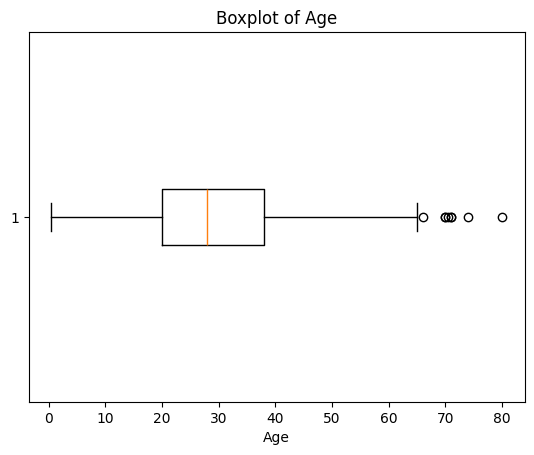

In [15]:


plt.boxplot(df2['Age'].dropna(), vert=False)
plt.title("Boxplot of Age")
plt.xlabel("Age")
plt.show()



In [16]:
df3 = df2.fillna(df2.Age.mean())
df3.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

Data Transformation

In [17]:
df3.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare', 'Embarked'],
      dtype='object')

In [ ]:
#Encoding for the categorical column

In [18]:
df3['Sex'] = df3['Sex'].astype(str).str.strip().str.lower()
print(df3['Sex'].unique())  # Should now be ['male', 'female', 'nan', ...]


#Hot encoding for Embarked

['male' 'female']


In [19]:
df3['Sex'] = df3['Sex'].map({'male': 1, 'female': 0})


In [20]:
print(df3['Sex'].isnull().sum())

0


In [21]:
print(df3['Sex'].unique())
print(df3['Sex'].dtype)


[1 0]
int64


In [22]:

df3 = pd.get_dummies(df3, columns=['Embarked'], drop_first=True)


In [23]:
X = df3[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']]
Y = df3['Survived']


In [24]:
print(X['Sex'].unique())
print(X['Sex'].dtype)

[1 0]
int64


In [27]:
from sklearn.preprocessing import MinMaxScaler

# 1. Select the features (assuming df3 is already cleaned and encoded)
X = df3[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']].copy()

# 2. Identify numeric columns to scale
scale_cols = ['Age', 'Fare', 'SibSp', 'Parch']

# 3. Initialize the scaler
scaler = MinMaxScaler()

# 4. Apply scaling only to the numeric columns
X[scale_cols] = scaler.fit_transform(X[scale_cols])

# 5. View the scaled result
print(X.head())


   Pclass  Sex       Age  SibSp  Parch      Fare  Embarked_Q  Embarked_S
0       3    1  0.271174  0.125    0.0  0.014151           0           1
1       1    0  0.472229  0.125    0.0  0.139136           0           0
2       3    0  0.321438  0.000    0.0  0.015469           0           1
3       1    0  0.434531  0.125    0.0  0.103644           0           1
4       3    1  0.434531  0.000    0.0  0.015713           0           1


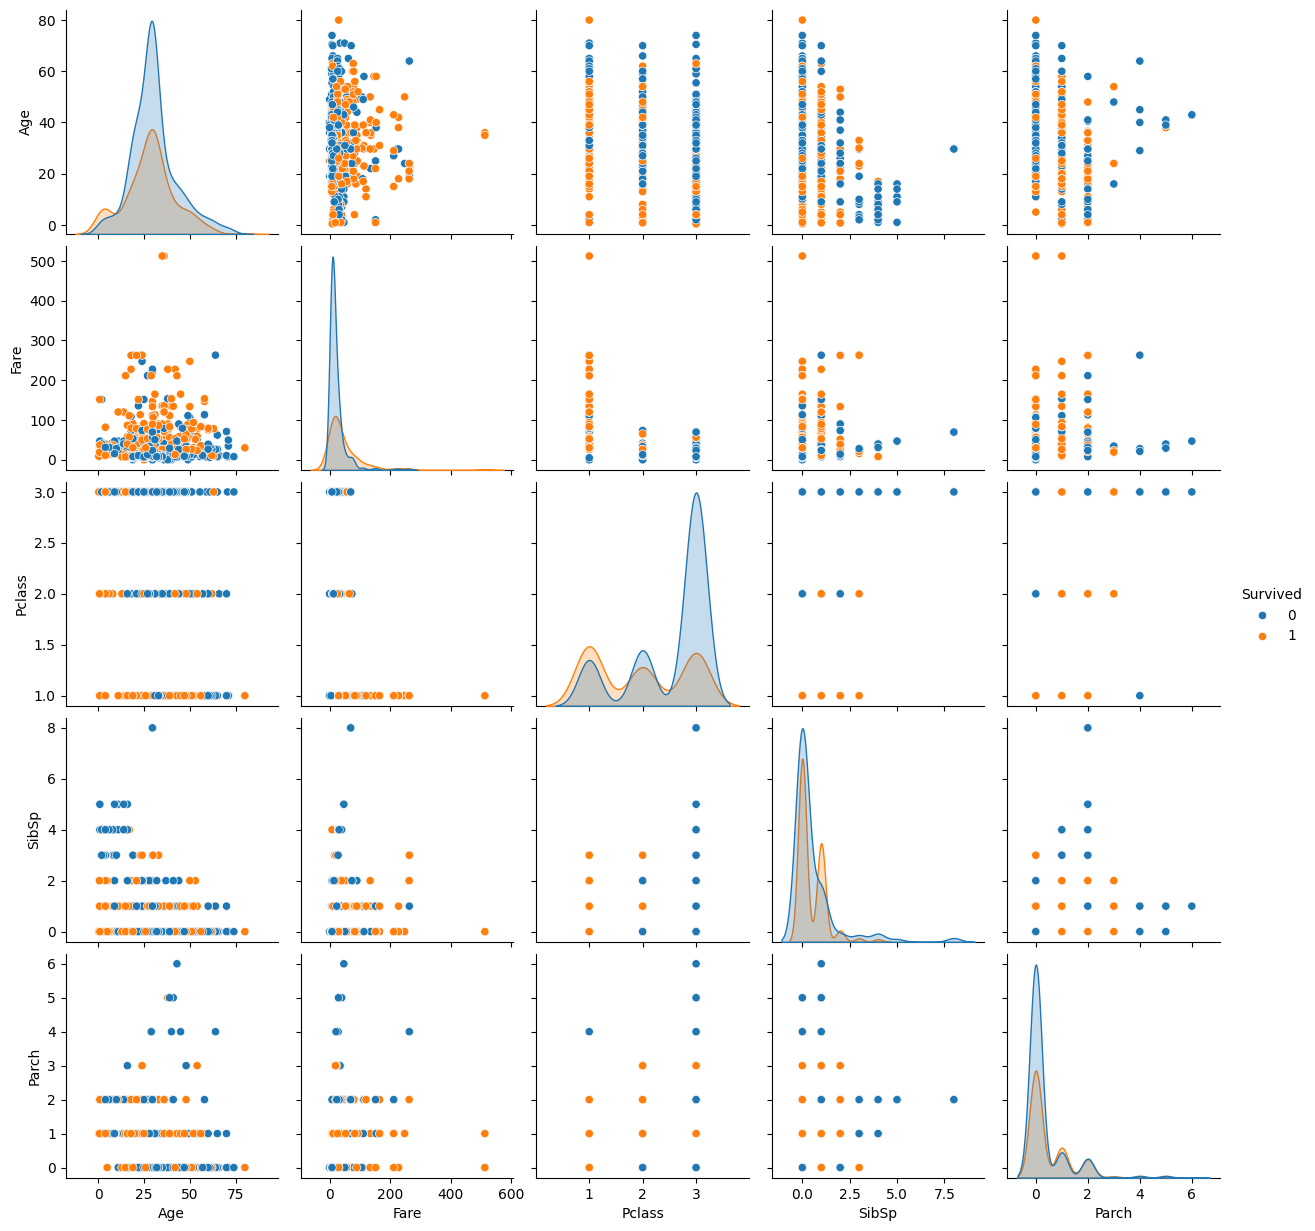

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# For quick visualization
sns.pairplot(df3, hue='Survived', vars=['Age', 'Fare', 'Pclass', 'SibSp', 'Parch'])
plt.show()



Training the Model:

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [30]:
# Final features (already encoded & scaled)
X = df3[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']]
y = df3['Survived']


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [32]:
log_model = LogisticRegression(max_iter=1000)  # add max_iter to avoid convergence warning
log_model.fit(X_train, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [33]:
y_pred = log_model.predict(X_test)



In [34]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7808988764044944

Confusion Matrix:
 [[85 24]
 [15 54]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.78      0.81       109
           1       0.69      0.78      0.73        69

    accuracy                           0.78       178
   macro avg       0.77      0.78      0.77       178
weighted avg       0.79      0.78      0.78       178

